# **Setting Environment**
1. Jalankan _uv init namaproject_
2. Jalankan _.venv\Scripts\activate_ utk aktivasi env
3. Buat file _requirements.txt_ isinya nama-nama libraries
4. Jalankan _uv add requirements.txt_ untuk menginstall library ke env
5. Jalankan _uv sync_ untuk sinkronasi lib di env dengan lib global di PC/Laptop

# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import openpyxl

# **Load Dataset**

In [2]:
dset = pd.read_excel('cyberbullying_tweets.xlsx',sheet_name='Sheet1')
dset.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
# Dekripsi
dset.info()

<class 'pandas.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47688 non-null  str  
 1   cyberbullying_type  47692 non-null  str  
dtypes: str(2)
memory usage: 745.3 KB


In [4]:
# Cek missing values
missing = pd.DataFrame({
    'Missing': dset.isnull().sum(),
    'Percentage': dset.isnull().mean() * 100
})

missing[missing['Missing'] > 0]

,Missing,Percentage
tweet_text,4,0.008387


In [5]:
# Makes sure missing values
dset[dset['tweet_text'].isnull()]

,tweet_text,cyberbullying_type
26865,NaN,other_cyberbullying
41106,NaN,ethnicity
41124,NaN,ethnicity
42050,NaN,ethnicity


In [6]:
# Hapus baris missing values 
dset.dropna(inplace=True)

In [7]:
dset['cat_cyberbullying'] = dset['cyberbullying_type'].map({
    'age' : 0,
    'ethnicity' : 1,
    'gender' : 2,
    'not_cyberbullying' : 3,
    'other_cyberbullying' : 4,
    'religion' : 5
})

# **Cleaning Data**

In [8]:
dset.info()

<class 'pandas.DataFrame'>
Index: 47688 entries, 0 to 47691
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   tweet_text          47688 non-null  str  
 1   cyberbullying_type  47688 non-null  str  
 2   cat_cyberbullying   47688 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.5 MB


# **EDA**

In [9]:
cat_bullying = dset.groupby(['cyberbullying_type'])['tweet_text'].count()\
    .reset_index(name='count')\
    .assign(
        pct = lambda x:x['count']/x['count'].sum(),
    )

cat_bullying

,cyberbullying_type,count,pct
0,age,7992,0.167589
1,ethnicity,7958,0.166876
2,gender,7973,0.167191
3,not_cyberbullying,7945,0.166604
4,other_cyberbullying,7822,0.164024
5,religion,7998,0.167715


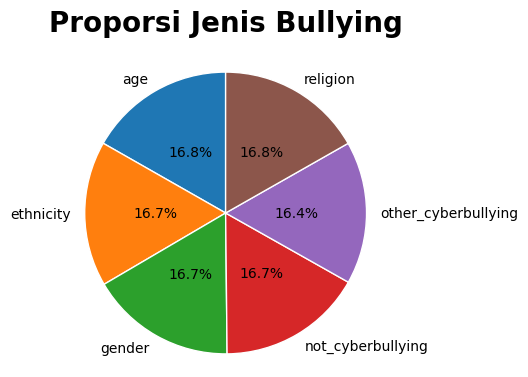

In [10]:
plt.figure(figsize=(4,4))

plt.pie(
    cat_bullying['count'],
    labels=cat_bullying['cyberbullying_type'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    pctdistance=0.5
)

plt.title('Proporsi Jenis Bullying', fontsize=20, fontweight='bold', loc='center', pad=20)
plt.axis('equal')
plt.show()